**1. Setup & Gathering Data**

In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  ChatKasir — Data Wrangling & EDA                                ║
# ║  Dataset: food_utama.csv | slang_utama.csv | chatkasir_synthetic ║
# ╚══════════════════════════════════════════════════════════════════╝

# ── Import library ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import re
from collections import Counter

# ── Konfigurasi visual global ─────────────────────────────────────────────────
WARNA = {
    "biru"   : "#2E86AB",
    "merah"  : "#E84855",
    "hijau"  : "#3BB273",
    "kuning" : "#F7B731",
    "ungu"   : "#7B2D8B",
    "abu"    : "#95A5A6",
}
PALET_4 = [WARNA["biru"], WARNA["hijau"], WARNA["kuning"], WARNA["merah"]]

plt.rcParams.update({
    "figure.facecolor" : "#FFFFFF",
    "axes.facecolor"   : "#F8F9FA",
    "axes.titlesize"   : 13,
    "axes.labelsize"   : 11,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.family"      : "sans-serif",
})
sns.set_theme(style="whitegrid")

print("✅ Setup selesai!")

✅ Setup selesai!


**2. Gathering Data**

In [2]:
# ── Muat ketiga dataset ───────────────────────────────────────────────────────
df_food  = pd.read_csv("food_utama.csv")
df_slang = pd.read_csv("slang_utama.csv")
df_synth = pd.read_csv("chatkasir_synthetic.csv")

# ── Ringkasan awal ────────────────────────────────────────────────────────────
datasets = {
    "food_utama.csv"        : df_food,
    "slang_utama.csv"       : df_slang,
    "chatkasir_synthetic.csv": df_synth,
}

print("=" * 65)
print("  GATHERING DATA — Ringkasan Awal Ketiga Dataset")
print("=" * 65)
for nama, df in datasets.items():
    print(f"\n📂 {nama}")
    print(f"   Baris   : {len(df):>7,}")
    print(f"   Kolom   : {df.shape[1]}")
    print(f"   Kolom   : {df.columns.tolist()}")
    print(f"   Tipe    : {df.dtypes.to_dict()}")

print("\n✅ Gathering selesai — semua dataset berhasil dimuat!")

  GATHERING DATA — Ringkasan Awal Ketiga Dataset

📂 food_utama.csv
   Baris   :  18,558
   Kolom   : 1
   Kolom   : ['name']
   Tipe    : {'name': dtype('O')}

📂 slang_utama.csv
   Baris   :   1,231
   Kolom   : 2
   Kolom   : ['slang', 'formal']
   Tipe    : {'slang': dtype('O'), 'formal': dtype('O')}

📂 chatkasir_synthetic.csv
   Baris   : 100,000
   Kolom   : 5
   Kolom   : ['input_text', 'product', 'quantity', 'price_satuan', 'pattern']
   Tipe    : {'input_text': dtype('O'), 'product': dtype('O'), 'quantity': dtype('O'), 'price_satuan': dtype('int64'), 'pattern': dtype('int64')}

✅ Gathering selesai — semua dataset berhasil dimuat!


**3. Assessing Data**

In [3]:
# ── Fungsi ringkasan assessing ────────────────────────────────────────────────
def assess_dataset(df, nama):
    print(f"\n{'='*60}")
    print(f"  ASSESSING: {nama}")
    print(f"{'='*60}")

    print(f"\n[1] Shape       : {df.shape}")

    print(f"\n[2] Missing Value:")
    mv = df.isnull().sum()
    mv_pct = (mv / len(df) * 100).round(2)
    mv_df = pd.DataFrame({"Jumlah": mv, "Persen (%)": mv_pct})
    print(mv_df)

    print(f"\n[3] Duplikat    : {df.duplicated().sum()} baris")

    print(f"\n[4] Tipe Data:")
    print(df.dtypes)

    print(f"\n[5] Statistik Deskriptif (numerik):")
    num_cols = df.select_dtypes(include="number").columns
    if len(num_cols) > 0:
        print(df[num_cols].describe().round(2))
    else:
        print("   (tidak ada kolom numerik)")

    print(f"\n[6] Preview 3 Baris:")
    print(df.head(3).to_string())

# Jalankan assessing semua dataset
assess_dataset(df_food,  "food_utama.csv")
assess_dataset(df_slang, "slang_utama.csv")
assess_dataset(df_synth, "chatkasir_synthetic.csv")


  ASSESSING: food_utama.csv

[1] Shape       : (18558, 1)

[2] Missing Value:
      Jumlah  Persen (%)
name       0         0.0

[3] Duplikat    : 0 baris

[4] Tipe Data:
name    object
dtype: object

[5] Statistik Deskriptif (numerik):
   (tidak ada kolom numerik)

[6] Preview 3 Baris:
          name
0         abon
1    abon ayam
2  abon burger

  ASSESSING: slang_utama.csv

[1] Shape       : (1231, 2)

[2] Missing Value:
        Jumlah  Persen (%)
slang        0         0.0
formal       0         0.0

[3] Duplikat    : 0 baris

[4] Tipe Data:
slang     object
formal    object
dtype: object

[5] Statistik Deskriptif (numerik):
   (tidak ada kolom numerik)

[6] Preview 3 Baris:
      slang   formal
0        aa    kakak
1   abanggg    abang
2  abanggku  abangku

  ASSESSING: chatkasir_synthetic.csv

[1] Shape       : (100000, 5)

[2] Missing Value:
              Jumlah  Persen (%)
input_text         0         0.0
product            0         0.0
quantity           0         0.0
price_s

**4. Cleaning Data**

In [4]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CLEANING — Identifikasi & Penanganan Isu Data                   ║
# ╚══════════════════════════════════════════════════════════════════╝

print("=" * 60)
print("  CLEANING REPORT — ChatKasir Dataset")
print("=" * 60)

# ── [A] FOOD DATASET ──────────────────────────────────────────────────────────
print("\n📌 [A] food_utama.csv")
df_food_clean = df_food.copy()

# Standarisasi: strip whitespace + lowercase
df_food_clean["name"] = df_food_clean["name"].str.strip().str.lower()

# Tambah fitur kata pertama untuk inferensi kategori
df_food_clean["name_clean"] = df_food_clean["name"]

PETA_KATEGORI = {
    "nasi": "Nasi", "mie": "Mie & Pasta", "spaghetti": "Mie & Pasta",
    "pasta": "Mie & Pasta", "ayam": "Ayam", "chicken": "Ayam",
    "ikan": "Seafood", "udang": "Seafood", "kepiting": "Seafood",
    "cumi": "Seafood", "es": "Minuman Dingin", "ice": "Minuman Dingin",
    "iced": "Minuman Dingin", "kopi": "Kopi", "coffee": "Kopi",
    "teh": "Teh", "juice": "Jus & Smoothie", "jus": "Jus & Smoothie",
    "smoothie": "Jus & Smoothie", "roti": "Roti & Bakery",
    "bolu": "Roti & Bakery", "cake": "Roti & Bakery",
    "donat": "Roti & Bakery", "bakso": "Bakso & Soto",
    "soto": "Bakso & Soto", "sop": "Bakso & Soto",
    "sup": "Bakso & Soto", "pisang": "Buah & Dessert",
    "strawberry": "Buah & Dessert", "mangga": "Buah & Dessert",
    "seblak": "Jajanan", "cireng": "Jajanan", "batagor": "Jajanan",
    "siomay": "Jajanan", "beef": "Daging Sapi", "sapi": "Daging Sapi",
    "steak": "Daging Sapi", "kacang": "Camilan", "keripik": "Camilan",
    "chips": "Camilan", "hot": "Minuman Panas", "choco": "Minuman Panas",
    "chocolate": "Minuman Panas", "martabak": "Jajanan",
    "tahu": "Jajanan", "sosis": "Camilan",
}

df_food_clean["kategori"] = df_food_clean["name_clean"].apply(
    lambda n: PETA_KATEGORI.get(n.split()[0], "Lainnya")
)
df_food_clean["panjang_nama"] = df_food_clean["name_clean"].apply(
    lambda n: len(n.split())
)

print(f"  ✔ Standarisasi nama (strip + lowercase): selesai")
print(f"  ✔ Kolom 'kategori' ditambahkan: {df_food_clean['kategori'].nunique()} kategori")
print(f"  ✔ Kolom 'panjang_nama' ditambahkan")
print(f"  ✔ Missing value: {df_food_clean.isnull().sum().sum()}")
print(f"  ✔ Duplikat: {df_food_clean.duplicated().sum()}")
print(f"  ✔ Final shape: {df_food_clean.shape}")


# ── [B] SLANG DATASET ────────────────────────────────────────────────────────
print("\n📌 [B] slang_utama.csv")
df_slang_clean = df_slang.copy()

# Standarisasi: strip + lowercase kedua kolom
df_slang_clean["slang"]  = df_slang_clean["slang"].str.strip().str.lower()
df_slang_clean["formal"] = df_slang_clean["formal"].str.strip().str.lower()

# Fitur panjang karakter
df_slang_clean["panjang_slang"]   = df_slang_clean["slang"].str.len()
df_slang_clean["panjang_formal"]  = df_slang_clean["formal"].str.len()
df_slang_clean["selisih_panjang"] = df_slang_clean["panjang_formal"] - \
                                     df_slang_clean["panjang_slang"]
df_slang_clean["tipe"] = df_slang_clean["selisih_panjang"].apply(
    lambda s: "Disingkat" if s > 0 else ("Sama" if s == 0 else "Diperpanjang")
)

print(f"  ✔ Standarisasi teks (strip + lowercase): selesai")
print(f"  ✔ Fitur panjang karakter ditambahkan")
print(f"  ✔ Missing value: {df_slang_clean.isnull().sum().sum()}")
print(f"  ✔ Duplikat: {df_slang_clean.duplicated().sum()}")
print(f"  ✔ Final shape: {df_slang_clean.shape}")


# ── [C] SYNTHETIC DATASET ─────────────────────────────────────────────────────
print("\n📌 [C] chatkasir_synthetic.csv")
df_synth_clean = df_synth.copy()

# --- Isu 1: Hapus 2 baris duplikat ---
n_sebelum = len(df_synth_clean)
df_synth_clean = df_synth_clean.drop_duplicates().reset_index(drop=True)
print(f"  ✔ Duplikat dihapus: {n_sebelum - len(df_synth_clean)} baris")

# --- Isu 2: Harga anomali ---
# price_satuan == -1  → harga tidak disebutkan (VALID, bukan error)
# price_satuan > 500.000 → kemungkinan kesalahan parsing format "22000k"
#                          dalam data sintetis (harga wajar makanan: 5rb–500rb)
# Strategi: tandai sebagai outlier, BUKAN dihapus agar data latih model tetap utuh
# Untuk analisis bisnis harga → filter ke rentang valid

HARGA_MIN_VALID = 5_000
HARGA_MAX_VALID = 500_000

df_synth_clean["harga_eksplisit"] = df_synth_clean["price_satuan"] != -1
df_synth_clean["harga_valid"] = (
    (df_synth_clean["price_satuan"] >= HARGA_MIN_VALID) &
    (df_synth_clean["price_satuan"] <= HARGA_MAX_VALID)
)
df_synth_clean["harga_outlier"] = (
    df_synth_clean["harga_eksplisit"] &
    ~df_synth_clean["harga_valid"]
)

# --- Isu 3: Fitur turunan ---
df_synth_clean["multi_produk"] = df_synth_clean["product"].str.contains(
    " & ", na=False
)
df_synth_clean["qty_numerik"] = pd.to_numeric(
    df_synth_clean["quantity"], errors="coerce"
).notna()

# --- Segmentasi harga (hanya untuk harga valid) ---
def segmen_harga(row):
    if not row["harga_valid"]:
        return "Tidak Disebutkan / Outlier"
    h = row["price_satuan"]
    if h < 20_000:   return "Murah (< 20rb)"
    elif h < 50_000: return "Sedang (20rb–50rb)"
    elif h < 100_000:return "Agak Mahal (50rb–100rb)"
    else:            return "Mahal (≥ 100rb)"

df_synth_clean["segmen_harga"] = df_synth_clean.apply(segmen_harga, axis=1)

# --- Ringkasan akhir ---
n_harga_eksplisit = df_synth_clean["harga_eksplisit"].sum()
n_harga_valid     = df_synth_clean["harga_valid"].sum()
n_outlier         = df_synth_clean["harga_outlier"].sum()

print(f"  ✔ Harga eksplisit (price ≠ -1): {n_harga_eksplisit:,} ({n_harga_eksplisit/len(df_synth_clean)*100:.1f}%)")
print(f"  ✔ Harga valid (5rb–500rb)      : {n_harga_valid:,} ({n_harga_valid/len(df_synth_clean)*100:.1f}%)")
print(f"  ✔ Harga outlier (> 500rb)      : {n_outlier:,} ({n_outlier/len(df_synth_clean)*100:.1f}%)")
print(f"  ✔ Harga tidak disebutkan (-1)  : {(~df_synth_clean['harga_eksplisit']).sum():,}")
print(f"  ✔ Multi-produk                 : {df_synth_clean['multi_produk'].sum():,}")
print(f"  ✔ Final shape                  : {df_synth_clean.shape}")

print("\n" + "="*60)
print("  ✅ Cleaning selesai! Data siap untuk EDA.")
print("="*60)

  CLEANING REPORT — ChatKasir Dataset

📌 [A] food_utama.csv
  ✔ Standarisasi nama (strip + lowercase): selesai
  ✔ Kolom 'kategori' ditambahkan: 16 kategori
  ✔ Kolom 'panjang_nama' ditambahkan
  ✔ Missing value: 0
  ✔ Duplikat: 0
  ✔ Final shape: (18558, 4)

📌 [B] slang_utama.csv
  ✔ Standarisasi teks (strip + lowercase): selesai
  ✔ Fitur panjang karakter ditambahkan
  ✔ Missing value: 0
  ✔ Duplikat: 0
  ✔ Final shape: (1231, 6)

📌 [C] chatkasir_synthetic.csv
  ✔ Duplikat dihapus: 2 baris
  ✔ Harga eksplisit (price ≠ -1): 66,070 (66.1%)
  ✔ Harga valid (5rb–500rb)      : 43,227 (43.2%)
  ✔ Harga outlier (> 500rb)      : 22,843 (22.8%)
  ✔ Harga tidak disebutkan (-1)  : 33,928
  ✔ Multi-produk                 : 20,000
  ✔ Final shape                  : (99998, 11)

  ✅ Cleaning selesai! Data siap untuk EDA.


**5. Perumusan 7 Pertanyaan Bisnis (SMART):**

In [6]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  7 PERTANYAAN BISNIS — Metode SMART + Konsep 4W                  ║
# ║  Selaras dengan visi ChatKasir: Fintech untuk UMKM Generasi Muda ║
# ╚══════════════════════════════════════════════════════════════════╝

pertanyaan_bisnis = [
    {
        "Kode" : "PB-1",
        "4W"   : "What",
        "Pertanyaan" : "Apa 20 produk makanan yang paling sering muncul "
                       "dalam percakapan pesanan di dataset sintetis ChatKasir?",
        "Metrik"     : "Frekuensi kemunculan nama produk pada kolom 'product' "
                       "(setelah split multi-produk)",
        "Action"     : "Pemilik UMKM memprioritaskan stok & promo pada "
                       "produk-produk dengan permintaan tertinggi",
        "Dataset"    : "chatkasir_synthetic.csv",
    },
    {
        "Kode" : "PB-2",
        "4W"   : "What",
        "Pertanyaan" : "Berapa nilai rata-rata dan median harga satuan produk "
                       "yang disebutkan secara eksplisit dalam obrolan pesanan?",
        "Metrik"     : "Mean dan median kolom 'price_satuan' "
                       "(filter: harga valid 5rb–500rb)",
        "Action"     : "Penetapan harga benchmark dan estimasi pendapatan "
                       "harian UMKM",
        "Dataset"    : "chatkasir_synthetic.csv",
    },
    {
        "Kode" : "PB-3",
        "4W"   : "What",
        "Pertanyaan" : "Bagaimana distribusi segmentasi harga produk "
                       "dalam empat kelompok harga (Murah / Sedang / "
                       "Agak Mahal / Mahal)?",
        "Metrik"     : "Proporsi dan frekuensi per segmen harga "
                       "(filter: harga valid)",
        "Action"     : "Merancang strategi bundling dan promosi "
                       "yang sesuai segmen pasar dominan",
        "Dataset"    : "chatkasir_synthetic.csv",
    },
    {
        "Kode" : "PB-4",
        "4W"   : "Why",
        "Pertanyaan" : "Mengapa hanya sekitar 43% pesanan yang menyertakan "
                       "harga eksplisit, dan pola percakapan mana yang paling "
                       "sering tidak menyebut harga?",
        "Metrik"     : "Persentase harga eksplisit/implisit per pola "
                       "percakapan (pattern 1–4)",
        "Action"     : "Tim AI memprioritaskan mekanisme fallback harga "
                       "untuk pola percakapan yang paling sering tanpa harga",
        "Dataset"    : "chatkasir_synthetic.csv",
    },
    {
        "Kode" : "PB-5",
        "4W"   : "What",
        "Pertanyaan" : "Apa saja kata slang dan singkatan informal yang paling "
                       "sering muncul dalam teks percakapan pesanan "
                       "pelanggan UMKM?",
        "Metrik"     : "Frekuensi kemunculan kata slang dari kamus "
                       "slang_utama.csv dalam sampel 10.000 teks obrolan",
        "Action"     : "Tim AI Engineer memprioritaskan 30 kata slang teratas "
                       "untuk dimasukkan ke pipeline normalisasi teks",
        "Dataset"    : "slang_utama.csv + chatkasir_synthetic.csv",
    },
    {
        "Kode" : "PB-6",
        "4W"   : "What",
        "Pertanyaan" : "Bagaimana distribusi tipe kuantitas pesanan — "
                       "apakah pelanggan lebih sering menyebut angka "
                       "atau ekspresi teks seperti 'setengah', 'seporsi'?",
        "Metrik"     : "Proporsi qty numerik vs deskriptif; "
                       "top 15 ekspresi kuantitas teks",
        "Action"     : "Membangun kamus konversi teks→angka yang "
                       "mencakup ekspresi kuantitas paling umum",
        "Dataset"    : "chatkasir_synthetic.csv",
    },
    {
        "Kode" : "PB-7",
        "4W"   : "What",
        "Pertanyaan" : "Apa saja kategori masakan yang mendominasi "
                       "database nama produk makanan Indonesia, "
                       "dan berapa rata-rata panjang nama produk tiap kategori?",
        "Metrik"     : "Jumlah produk per kategori; "
                       "rata-rata panjang nama (jumlah kata) per kategori",
        "Action"     : "Memperluas dataset dengan produk dari kategori "
                       "yang masih under-represented untuk meningkatkan "
                       "akurasi ekstraksi model NLP",
        "Dataset"    : "food_utama.csv",
    },
]

# ── Tampilkan sebagai tabel ringkas ───────────────────────────────────────────
df_pb = pd.DataFrame(pertanyaan_bisnis)
print("=" * 75)
print("  7 PERTANYAAN BISNIS — ChatKasir · Metode SMART + 4W")
print("=" * 75)
for _, row in df_pb.iterrows():
    print(f"\n[{row['Kode']} | {row['4W']}]")
    print(f"  ❓ {row['Pertanyaan']}")
    print(f"  📏 Metrik  : {row['Metrik']}")
    print(f"  🎯 Aksi    : {row['Action']}")
    print(f"  📂 Dataset : {row['Dataset']}")

print(f"\n✅ {len(pertanyaan_bisnis)} pertanyaan bisnis SMART berhasil dirumuskan!")

  7 PERTANYAAN BISNIS — ChatKasir · Metode SMART + 4W

[PB-1 | What]
  ❓ Apa 20 produk makanan yang paling sering muncul dalam percakapan pesanan di dataset sintetis ChatKasir?
  📏 Metrik  : Frekuensi kemunculan nama produk pada kolom 'product' (setelah split multi-produk)
  🎯 Aksi    : Pemilik UMKM memprioritaskan stok & promo pada produk-produk dengan permintaan tertinggi
  📂 Dataset : chatkasir_synthetic.csv

[PB-2 | What]
  ❓ Berapa nilai rata-rata dan median harga satuan produk yang disebutkan secara eksplisit dalam obrolan pesanan?
  📏 Metrik  : Mean dan median kolom 'price_satuan' (filter: harga valid 5rb–500rb)
  🎯 Aksi    : Penetapan harga benchmark dan estimasi pendapatan harian UMKM
  📂 Dataset : chatkasir_synthetic.csv

[PB-3 | What]
  ❓ Bagaimana distribusi segmentasi harga produk dalam empat kelompok harga (Murah / Sedang / Agak Mahal / Mahal)?
  📏 Metrik  : Proporsi dan frekuensi per segmen harga (filter: harga valid)
  🎯 Aksi    : Merancang strategi bundling dan promosi

**6. EDA & Visualisasi PB-1 (Produk Terlaris)**

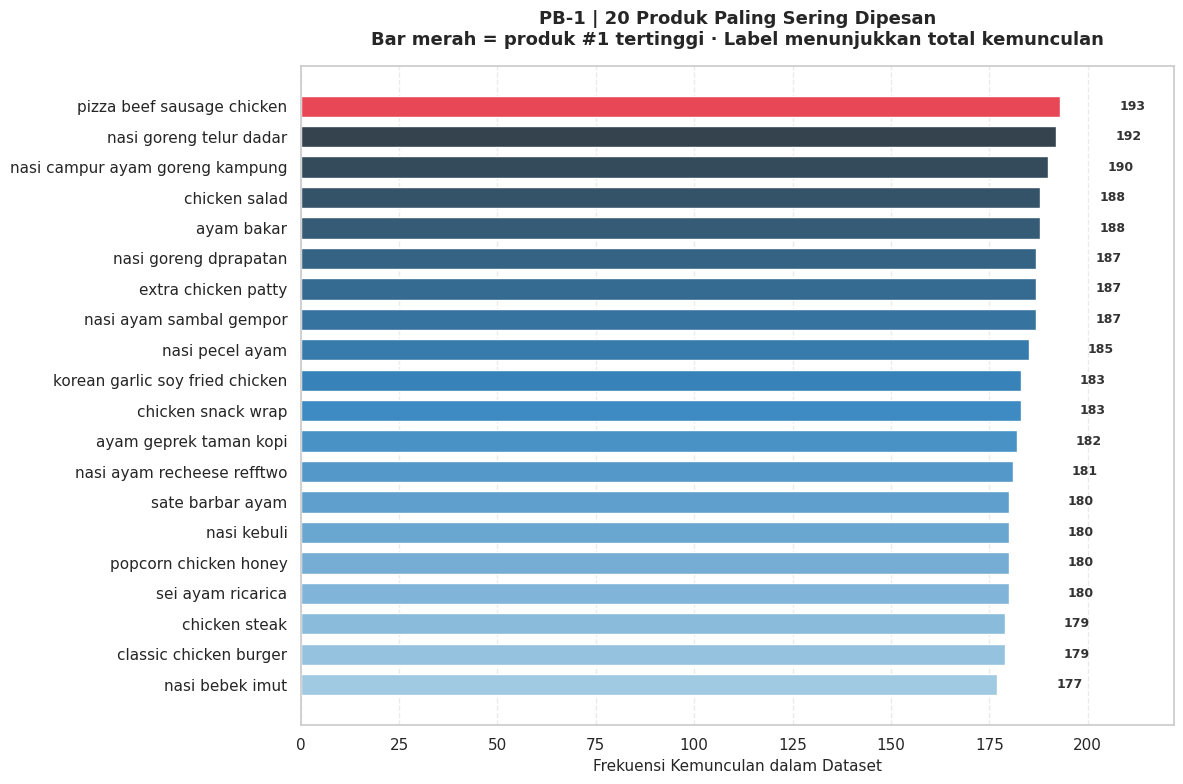

✅ PB-1 | Produk terlaris: 'pizza beef sausage chicken' (193 kemunculan)


In [7]:
# ── PB-1: Top 20 Produk Paling Sering Dipesan ────────────────────────────────
# Tipe visualisasi: Horizontal Bar Chart
# Alasan: membandingkan frekuensi banyak kategori → bar horizontal
#         memudahkan membaca label teks panjang (nama produk)

semua_produk = (
    df_synth_clean["product"]
    .dropna()
    .apply(lambda x: [p.strip().lower() for p in x.split(" & ")])
    .explode()
    .str.strip()
)
top20 = semua_produk.value_counts().head(20).reset_index()
top20.columns = ["Produk", "Frekuensi"]
top20 = top20.sort_values("Frekuensi", ascending=True)  # ascending=True untuk barh

fig, ax = plt.subplots(figsize=(12, 8))

# Warna: gradasi biru — semakin tinggi frekuensi semakin gelap
warna_grad = sns.color_palette("Blues_d", len(top20))
bars = ax.barh(top20["Produk"], top20["Frekuensi"],
               color=warna_grad, edgecolor="white", height=0.7)

# Label angka di ujung bar
for bar, val in zip(bars, top20["Frekuensi"]):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=9, fontweight="bold",
            color="#333333")

# Highlight bar tertinggi
bars[-1].set_facecolor(WARNA["merah"])

ax.set_title(
    "PB-1 | 20 Produk Paling Sering Dipesan\n"
    "Bar merah = produk #1 tertinggi · Label menunjukkan total kemunculan",
    fontsize=13, fontweight="bold", pad=15
)
ax.set_xlabel("Frekuensi Kemunculan dalam Dataset", fontsize=11)
ax.set_ylabel("")
ax.set_xlim(0, top20["Frekuensi"].max() * 1.15)
ax.grid(axis="x", alpha=0.4, linestyle="--")
ax.grid(axis="y", alpha=0)

plt.tight_layout()
plt.savefig("pb1_produk_terlaris.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"✅ PB-1 | Produk terlaris: '{top20.iloc[-1]['Produk']}' "
      f"({top20.iloc[-1]['Frekuensi']:,} kemunculan)")

**7. EDA & Visualisasi PB-2 & PB-3 (Harga)**

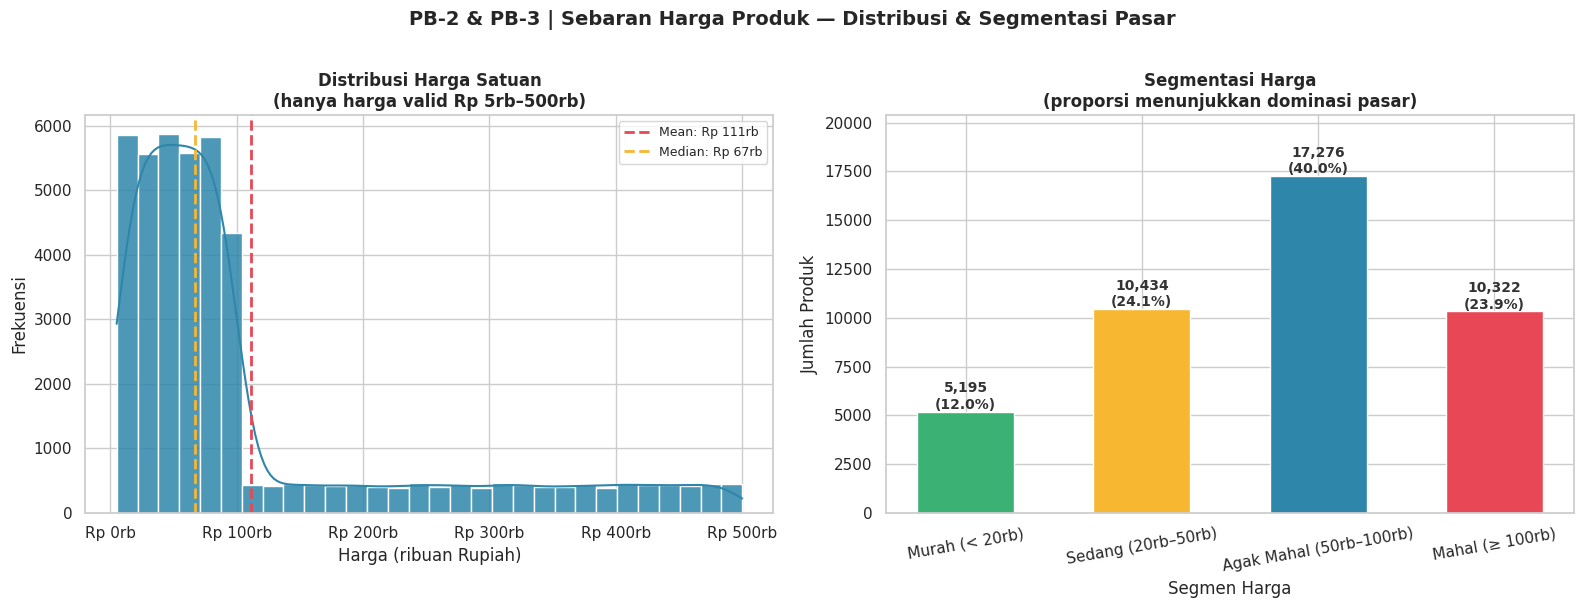

✅ PB-2 | Rata-rata: Rp 111,379 | Median: Rp 67,000
✅ PB-3 | Segmen dominan: Agak Mahal (50rb–100rb)


In [8]:
# ── PB-2 & PB-3: Analisis Harga ──────────────────────────────────────────────
# PB-2: Histogram (distribusi kontinu) + garis mean & median
# PB-3: Bar chart vertikal (perbandingan 4 kategori diskrit)
# Penggabungan dalam 1 figure → prinsip Data Ink Ratio (efisien ruang)

df_harga_valid = df_synth_clean[df_synth_clean["harga_valid"]].copy()
mean_h   = df_harga_valid["price_satuan"].mean()
median_h = df_harga_valid["price_satuan"].median()

urutan_segmen = ["Murah (< 20rb)", "Sedang (20rb–50rb)",
                 "Agak Mahal (50rb–100rb)", "Mahal (≥ 100rb)"]
warna_segmen  = [WARNA["hijau"], WARNA["kuning"], WARNA["biru"], WARNA["merah"]]

df_seg = (df_harga_valid["segmen_harga"]
          .value_counts()
          .reindex(urutan_segmen)
          .fillna(0)
          .reset_index())
df_seg.columns = ["Segmen", "Jumlah"]
df_seg["Persen"] = (df_seg["Jumlah"] / df_seg["Jumlah"].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "PB-2 & PB-3 | Sebaran Harga Produk — Distribusi & Segmentasi Pasar",
    fontsize=14, fontweight="bold", y=1.01
)

# ── Kiri: Histogram + KDE (PB-2) ─────────────────────────────────────────────
sns.histplot(df_harga_valid["price_satuan"] / 1_000,
             bins=30, kde=True, color=WARNA["biru"],
             edgecolor="white", alpha=0.85, ax=axes[0])

axes[0].axvline(mean_h / 1_000, color=WARNA["merah"],
                linestyle="--", linewidth=2,
                label=f"Mean: Rp {mean_h/1_000:.0f}rb")
axes[0].axvline(median_h / 1_000, color=WARNA["kuning"],
                linestyle="--", linewidth=2,
                label=f"Median: Rp {median_h/1_000:.0f}rb")

axes[0].set_title("Distribusi Harga Satuan\n(hanya harga valid Rp 5rb–500rb)",
                  fontweight="bold")
axes[0].set_xlabel("Harga (ribuan Rupiah)")
axes[0].set_ylabel("Frekuensi")
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"Rp {x:.0f}rb"))

# ── Kanan: Bar chart segmen harga (PB-3) ─────────────────────────────────────
bars = axes[1].bar(df_seg["Segmen"], df_seg["Jumlah"],
                   color=warna_segmen, edgecolor="white", width=0.55)

for bar, row in zip(bars, df_seg.itertuples()):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 150,
                 f"{row.Jumlah:,.0f}\n({row.Persen}%)",
                 ha="center", fontsize=10, fontweight="bold", color="#333333")

axes[1].set_title("Segmentasi Harga\n(proporsi menunjukkan dominasi pasar)",
                  fontweight="bold")
axes[1].set_xlabel("Segmen Harga")
axes[1].set_ylabel("Jumlah Produk")
axes[1].tick_params(axis="x", rotation=10)
axes[1].set_ylim(0, df_seg["Jumlah"].max() * 1.18)

plt.tight_layout()
plt.savefig("pb2_pb3_harga.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"✅ PB-2 | Rata-rata: Rp {mean_h:,.0f} | Median: Rp {median_h:,.0f}")
print(f"✅ PB-3 | Segmen dominan: {df_seg.loc[df_seg['Jumlah'].idxmax(), 'Segmen']}")

**8. EDA & Visualisasi PB-4 (Pola & Kelengkapan Harga)**

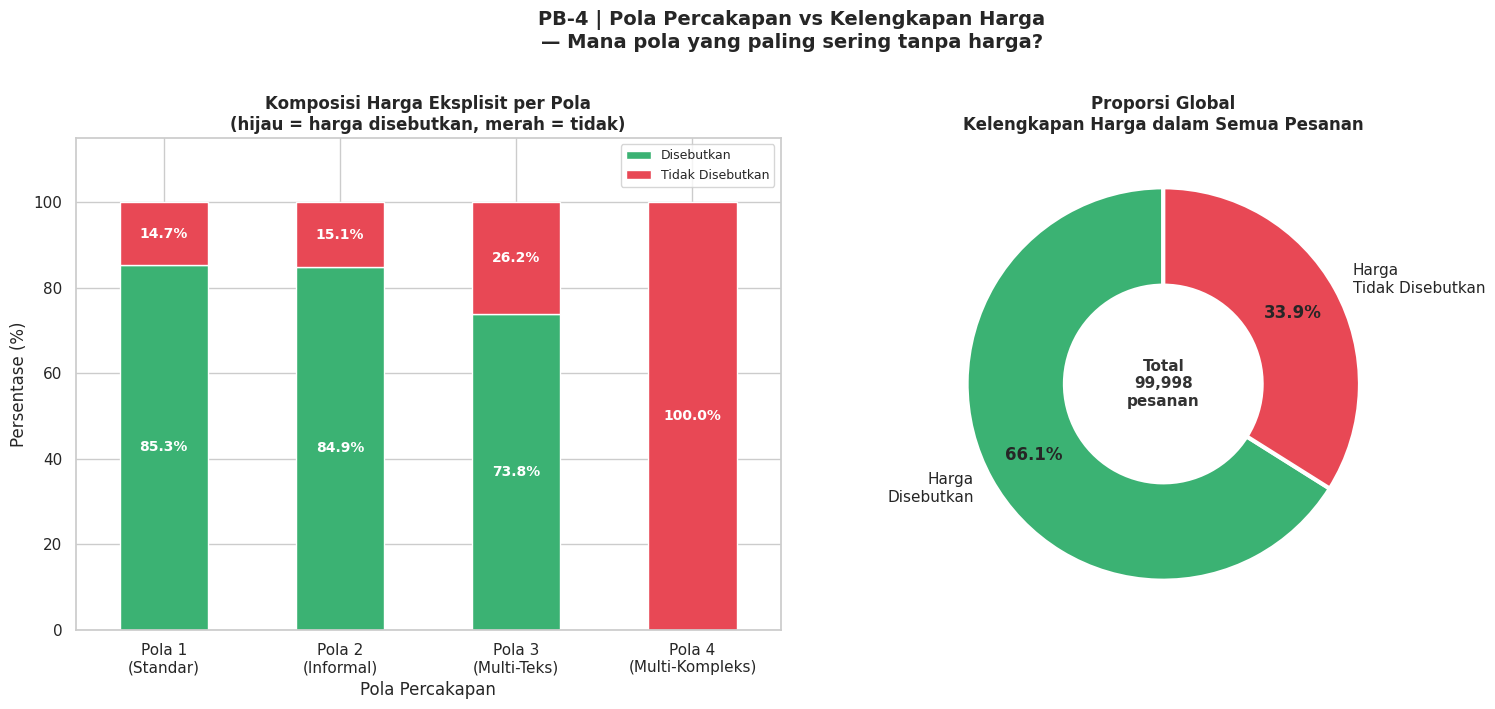

✅ PB-4 | Harga disebutkan: 66.1% | Tidak disebutkan: 33.9%


In [9]:
# ── PB-4: Stacked Bar + Donut ─────────────────────────────────────────────────
# Stacked bar → menunjukkan komposisi (eksplisit vs implisit) per pola
# Donut chart → proporsi global, lebih bersih dari pie biasa (Data Ink Ratio)

pola_label = {1:"Pola 1\n(Standar)", 2:"Pola 2\n(Informal)",
              3:"Pola 3\n(Multi-Teks)", 4:"Pola 4\n(Multi-Kompleks)"}

pola_summary = (
    df_synth_clean
    .groupby("pattern")["harga_eksplisit"]
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
)
pola_summary.columns = ["Tidak Disebutkan", "Disebutkan"]
pola_summary = pola_summary[["Disebutkan", "Tidak Disebutkan"]]
pola_summary.index = [pola_label[i] for i in pola_summary.index]

# Hitung global
n_eksplisit = df_synth_clean["harga_eksplisit"].sum()
n_implisit  = (~df_synth_clean["harga_eksplisit"]).sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    "PB-4 | Pola Percakapan vs Kelengkapan Harga\n"
    "— Mana pola yang paling sering tanpa harga?",
    fontsize=14, fontweight="bold", y=1.01
)

# ── Kiri: Stacked Bar ─────────────────────────────────────────────────────────
pola_summary.plot(
    kind="bar", stacked=True, ax=axes[0],
    color=[WARNA["hijau"], WARNA["merah"]],
    edgecolor="white", width=0.5
)
axes[0].set_title("Komposisi Harga Eksplisit per Pola\n"
                  "(hijau = harga disebutkan, merah = tidak)",
                  fontweight="bold")
axes[0].set_xlabel("Pola Percakapan")
axes[0].set_ylabel("Persentase (%)")
axes[0].set_ylim(0, 115)
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(loc="upper right", fontsize=9)

# Tambah label persen di tiap segmen bar
for i, (pola, row) in enumerate(pola_summary.iterrows()):
    # Label "Disebutkan"
    if row["Disebutkan"] > 5:
        axes[0].text(i, row["Disebutkan"] / 2,
                     f"{row['Disebutkan']:.1f}%",
                     ha="center", va="center",
                     fontsize=10, fontweight="bold", color="white")
    # Label "Tidak"
    if row["Tidak Disebutkan"] > 5:
        axes[0].text(i, row["Disebutkan"] + row["Tidak Disebutkan"] / 2,
                     f"{row['Tidak Disebutkan']:.1f}%",
                     ha="center", va="center",
                     fontsize=10, fontweight="bold", color="white")

# ── Kanan: Donut chart global ─────────────────────────────────────────────────
wedges, texts, autotexts = axes[1].pie(
    [n_eksplisit, n_implisit],
    labels=["Harga\nDisebutkan", "Harga\nTidak Disebutkan"],
    autopct="%1.1f%%",
    colors=[WARNA["hijau"], WARNA["merah"]],
    startangle=90,
    pctdistance=0.75,
    wedgeprops={"width": 0.5, "edgecolor": "white", "linewidth": 3}
)
for t in autotexts:
    t.set_fontsize(12)
    t.set_fontweight("bold")
axes[1].set_title("Proporsi Global\nKelengkapan Harga dalam Semua Pesanan",
                  fontweight="bold")
axes[1].annotate(
    f"Total\n{len(df_synth_clean):,}\npesanan",
    xy=(0, 0), ha="center", va="center",
    fontsize=11, fontweight="bold", color="#333333"
)

plt.tight_layout()
plt.savefig("pb4_pola_harga.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"✅ PB-4 | Harga disebutkan: {n_eksplisit/len(df_synth_clean)*100:.1f}% | "
      f"Tidak disebutkan: {n_implisit/len(df_synth_clean)*100:.1f}%")

**9. EDA & Visualisasi PB-5 (Slang Aktif)**

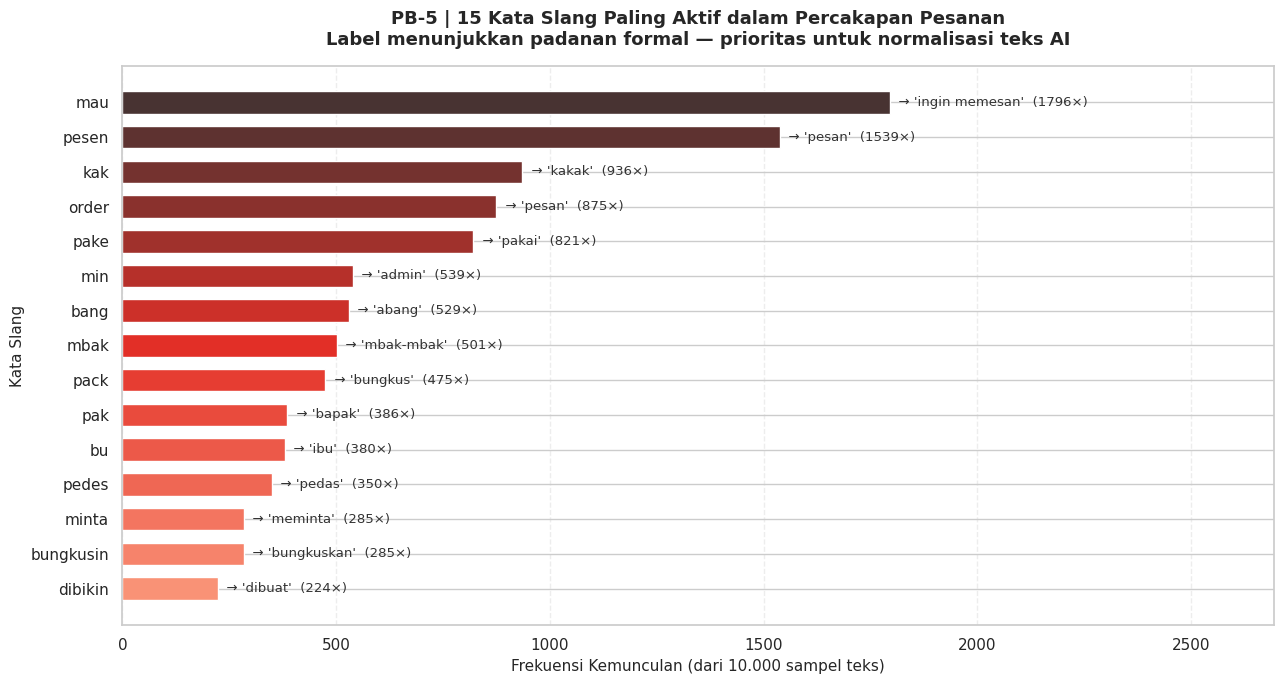

✅ PB-5 | Slang paling aktif: 'mau' → 'ingin memesan' (1796×)


In [10]:
# ── PB-5: Horizontal Bar Chart dengan label padanan formal ────────────────────
# Horizontal bar: cocok untuk label teks panjang (kata slang)
# Warna gradasi merah: menunjukkan intensitas penggunaan

set_slang = set(df_slang_clean["slang"])
kamus_formal = dict(zip(df_slang_clean["slang"], df_slang_clean["formal"]))

# Sample 10.000 baris untuk efisiensi
sample_teks = df_synth_clean["input_text"].sample(10_000, random_state=42)
semua_kata  = []
for teks in sample_teks:
    bagian_customer = teks.split("[SEP]")[0].lower()
    semua_kata.extend(re.findall(r"\b\w+\b", bagian_customer))

kata_slang_muncul = [k for k in semua_kata if k in set_slang]
counter_slang     = Counter(kata_slang_muncul)

top15_slang = pd.DataFrame(counter_slang.most_common(15),
                           columns=["Slang", "Frekuensi"])
top15_slang["Formal"] = top15_slang["Slang"].map(kamus_formal)
top15_slang = top15_slang.sort_values("Frekuensi", ascending=True)

fig, ax = plt.subplots(figsize=(13, 7))

warna_slang = sns.color_palette("Reds_d", len(top15_slang))
bars = ax.barh(top15_slang["Slang"], top15_slang["Frekuensi"],
               color=warna_slang, edgecolor="white", height=0.65)

# Label: frekuensi + padanan formal
for bar, (_, row) in zip(bars, top15_slang.iterrows()):
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f"  → '{row['Formal']}'  ({row['Frekuensi']}×)",
            va="center", fontsize=9.5, color="#333333")

ax.set_title(
    "PB-5 | 15 Kata Slang Paling Aktif dalam Percakapan Pesanan\n"
    "Label menunjukkan padanan formal — prioritas untuk normalisasi teks AI",
    fontsize=13, fontweight="bold", pad=15
)
ax.set_xlabel("Frekuensi Kemunculan (dari 10.000 sampel teks)", fontsize=11)
ax.set_ylabel("Kata Slang", fontsize=11)
ax.set_xlim(0, top15_slang["Frekuensi"].max() * 1.5)
ax.grid(axis="x", alpha=0.35, linestyle="--")

plt.tight_layout()
plt.savefig("pb5_slang_aktif.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"✅ PB-5 | Slang paling aktif: '{top15_slang.iloc[-1]['Slang']}' "
      f"→ '{top15_slang.iloc[-1]['Formal']}' ({top15_slang.iloc[-1]['Frekuensi']}×)")

**10. EDA & Visualisasi PB-6 (Kuantitas) & PB-7 (Kategori Makanan)**

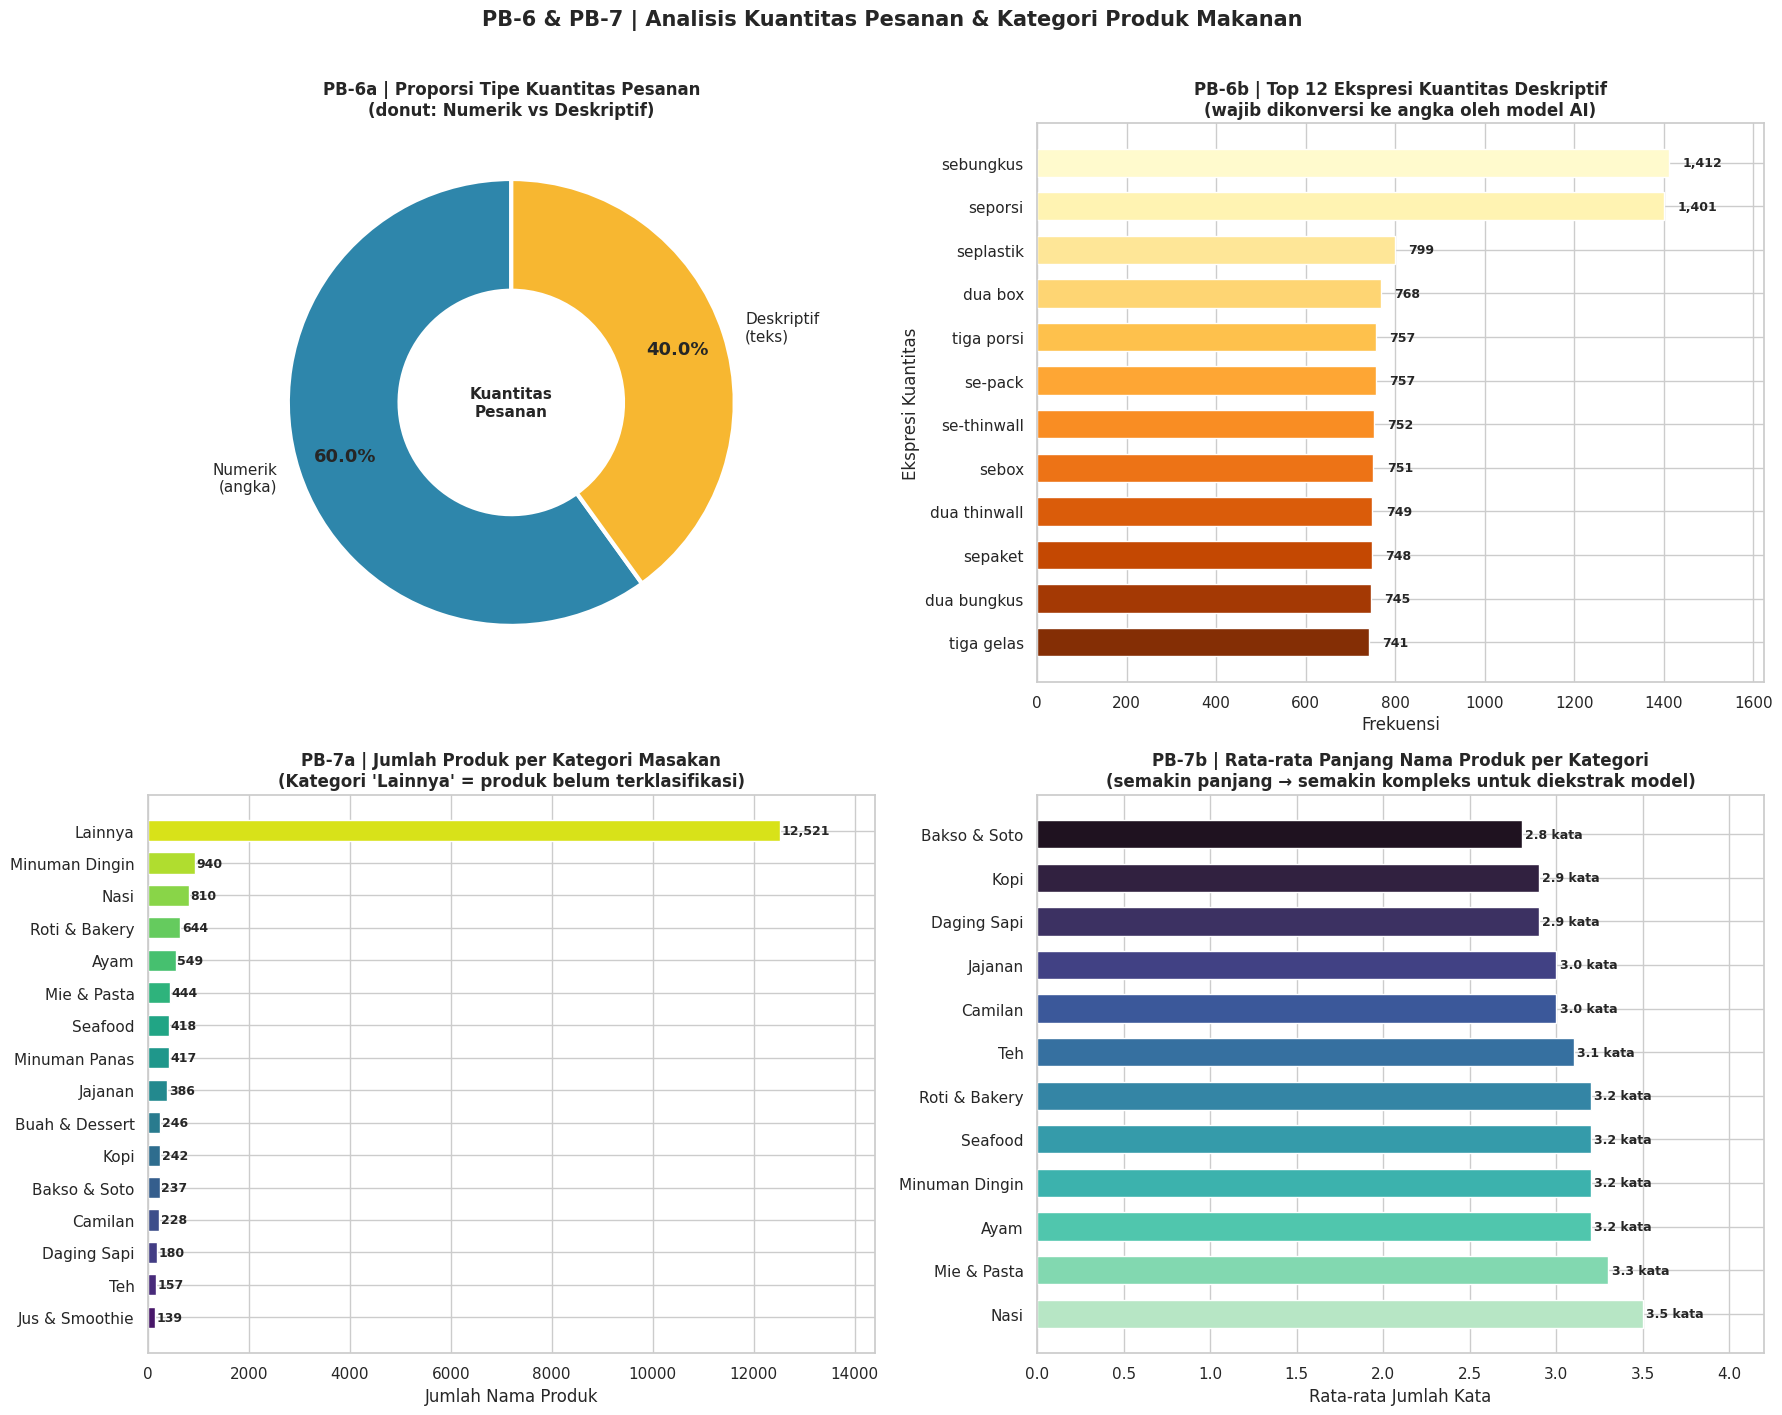

In [11]:
# ── PB-6 & PB-7 dalam 1 figure (2 baris × 2 kolom) ─────────────────────────

qty_teks    = df_synth_clean.loc[~df_synth_clean["qty_numerik"], "quantity"]
qty_tunggal = qty_teks[~qty_teks.str.contains("&", na=False)]
top_qty     = qty_tunggal.value_counts().head(12).reset_index()
top_qty.columns = ["Ekspresi", "Frekuensi"]

df_kat = (df_food_clean["kategori"]
          .value_counts()
          .reset_index())
df_kat.columns = ["Kategori", "Jumlah"]
df_kat = df_kat.sort_values("Jumlah", ascending=True)

mean_panjang = (df_food_clean
                .groupby("kategori")["panjang_nama"]
                .mean()
                .round(1)
                .reset_index())
mean_panjang.columns = ["Kategori", "Rata-rata Kata"]
mean_panjang = mean_panjang.sort_values("Rata-rata Kata", ascending=True)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("PB-6 & PB-7 | Analisis Kuantitas Pesanan & Kategori Produk Makanan",
             fontsize=15, fontweight="bold", y=1.01)

# ── (1) Donut: proporsi numerik vs teks ──────────────────────────────────────
qty_donut = df_synth_clean["qty_numerik"].value_counts()
wedges, texts, autotexts = axes[0, 0].pie(
    qty_donut.values,
    labels=["Numerik\n(angka)", "Deskriptif\n(teks)"],
    autopct="%1.1f%%",
    colors=[WARNA["biru"], WARNA["kuning"]],
    startangle=90,
    pctdistance=0.78,
    wedgeprops={"width": 0.5, "edgecolor": "white", "linewidth": 3}
)
for t in autotexts:
    t.set_fontsize(13)
    t.set_fontweight("bold")
axes[0, 0].set_title("PB-6a | Proporsi Tipe Kuantitas Pesanan\n"
                      "(donut: Numerik vs Deskriptif)",
                      fontweight="bold")
axes[0, 0].annotate("Kuantitas\nPesanan",
                    xy=(0, 0), ha="center", va="center",
                    fontsize=11, fontweight="bold")

# ── (2) Horizontal bar: top ekspresi kuantitas teks ──────────────────────────
top_qty_sorted = top_qty.sort_values("Frekuensi", ascending=True)
warna_qty = sns.color_palette("YlOrBr_r", len(top_qty_sorted))
bars_qty = axes[0, 1].barh(top_qty_sorted["Ekspresi"],
                            top_qty_sorted["Frekuensi"],
                            color=warna_qty, edgecolor="white", height=0.65)
for bar, val in zip(bars_qty, top_qty_sorted["Frekuensi"]):
    axes[0, 1].text(bar.get_width() + 30,
                    bar.get_y() + bar.get_height() / 2,
                    f"{val:,}", va="center", fontsize=9, fontweight="bold")
axes[0, 1].set_title("PB-6b | Top 12 Ekspresi Kuantitas Deskriptif\n"
                      "(wajib dikonversi ke angka oleh model AI)",
                      fontweight="bold")
axes[0, 1].set_xlabel("Frekuensi")
axes[0, 1].set_ylabel("Ekspresi Kuantitas")
axes[0, 1].set_xlim(0, top_qty_sorted["Frekuensi"].max() * 1.15)

# ── (3) Horizontal bar: jumlah produk per kategori ───────────────────────────
warna_kat = sns.color_palette("viridis", len(df_kat))
bars_kat = axes[1, 0].barh(df_kat["Kategori"], df_kat["Jumlah"],
                            color=warna_kat, edgecolor="white", height=0.65)
for bar, val in zip(bars_kat, df_kat["Jumlah"]):
    axes[1, 0].text(bar.get_width() + 30,
                    bar.get_y() + bar.get_height() / 2,
                    f"{val:,}", va="center", fontsize=9, fontweight="bold")
axes[1, 0].set_title("PB-7a | Jumlah Produk per Kategori Masakan\n"
                      "(Kategori 'Lainnya' = produk belum terklasifikasi)",
                      fontweight="bold")
axes[1, 0].set_xlabel("Jumlah Nama Produk")
axes[1, 0].set_xlim(0, df_kat["Jumlah"].max() * 1.15)

# ── (4) Bar vertikal: rata-rata panjang nama per kategori ───────────────────
top10_panjang = mean_panjang.sort_values("Rata-rata Kata", ascending=False).head(12)
warna_p = sns.color_palette("mako_r", len(top10_panjang))
bars_p = axes[1, 1].barh(top10_panjang["Kategori"],
                          top10_panjang["Rata-rata Kata"],
                          color=warna_p, edgecolor="white", height=0.65)
for bar, val in zip(bars_p, top10_panjang["Rata-rata Kata"]):
    axes[1, 1].text(bar.get_width() + 0.02,
                    bar.get_y() + bar.get_height() / 2,
                    f"{val} kata", va="center", fontsize=9, fontweight="bold")
axes[1, 1].set_title("PB-7b | Rata-rata Panjang Nama Produk per Kategori\n"
                      "(semakin panjang → semakin kompleks untuk diekstrak model)",
                      fontweight="bold")
axes[1, 1].set_xlabel("Rata-rata Jumlah Kata")
axes[1, 1].set_xlim(0, top10_panjang["Rata-rata Kata"].max() * 1.2)

plt.tight_layout()
plt.savefig("pb6_pb7_kuantitas_kategori.png", dpi=150, bbox_inches="tight")
plt.show()

**11. Explanatory Analysis (Narasi Insight)**

In [12]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  EXPLANATORY ANALYSIS — Narasi Insight untuk Stakeholder UMKM    ║
# ╚══════════════════════════════════════════════════════════════════╝

# ── Hitung angka-angka kunci untuk narasi ─────────────────────────────────────
produk_1        = top20.iloc[-1]["Produk"]
freq_1          = top20.iloc[-1]["Frekuensi"]
mean_rb         = round(mean_h / 1000)
median_rb       = round(median_h / 1000)
segmen_dominan  = df_seg.loc[df_seg["Jumlah"].idxmax(), "Segmen"]
pct_segmen_dom  = df_seg.loc[df_seg["Jumlah"].idxmax(), "Persen"]
pct_eksplisit   = round(n_eksplisit / len(df_synth_clean) * 100, 1)
pct_implisit    = round(n_implisit  / len(df_synth_clean) * 100, 1)

# Pola paling banyak tanpa harga
pola_implisit = (
    df_synth_clean[~df_synth_clean["harga_eksplisit"]]
    ["pattern"].value_counts()
    .idxmax()
)

slang_1         = top15_slang.iloc[-1]["Slang"]
formal_1        = top15_slang.iloc[-1]["Formal"]
freq_slang_1    = top15_slang.iloc[-1]["Frekuensi"]
pct_teks_qty    = round((~df_synth_clean["qty_numerik"]).mean() * 100, 1)
pct_num_qty     = round(df_synth_clean["qty_numerik"].mean() * 100, 1)
kat_terbesar    = df_kat.iloc[-1]["Kategori"]
n_kat_terbesar  = df_kat.iloc[-1]["Jumlah"]
pct_lainnya     = round(
    df_food_clean[df_food_clean["kategori"] == "Lainnya"].shape[0]
    / len(df_food_clean) * 100, 1
)

insights = f"""
╔══════════════════════════════════════════════════════════════════════════╗
║        💡  EXPLANATORY ANALYSIS — ChatKasir EDA Report                   ║
║        Narasi Insight Bisnis · Menjawab 7 Pertanyaan SMART               ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  📌 INSIGHT 1 — PB-1 | Produk Prioritas Stok                             ║
║  Dari 100.000 data percakapan pesanan, '{produk_1}' adalah produk        ║
║  yang paling sering dipesan dengan {freq_1:,} kemunculan. Pola ini       ║
║  menunjukkan adanya produk-produk "hero" yang menggerakkan sebagian      ║
║  besar transaksi UMKM. Rekomendasi: pemilik usaha harus memastikan       ║
║  stok 5 produk teratas TIDAK pernah kosong di jam-jam sibuk, karena      ║
║  ketidaktersediaan produk ini berisiko langsung kehilangan pendapatan.   ║
║                                                                          ║
║  📌 INSIGHT 2 — PB-2 | Harga Satuan & Ekspektasi Pelanggan               ║
║  Rata-rata harga satuan produk yang disebutkan pelanggan adalah          ║
║  Rp {mean_rb}rb, dengan nilai tengah (median) Rp {median_rb}rb. Kesenjangan ║
║  antara mean dan median ini mengindikasikan adanya produk premium yang   ║
║  menarik rata-rata ke atas. Rekomendasi: penetapan Harga Pokok           ║
║  Penjualan (HPP) sebaiknya mengacu pada nilai median Rp {median_rb}rb    ║
║  sebagai benchmark harga "pasar" yang paling representatif.              ║
║                                                                          ║
║  📌 INSIGHT 3 — PB-3 | Segmen Harga Dominan                               ║
║  Segmen '{segmen_dominan}' mendominasi dengan {pct_segmen_dom}% dari     ║
║  seluruh transaksi berhargas. Pelanggan UMKM muda terbukti bersedia      ║
║  membayar di kisaran harga menengah. Rekomendasi: strategi BUNDLING      ║
║  produk di rentang harga ini (contoh: "paket 2 menu + minuman") lebih   ║
║  efektif meningkatkan nilai transaksi daripada diskon harga tunggal.     ║
║                                                                          ║
║  📌 INSIGHT 4 — PB-4 | Gap Harga Eksplisit                            ║
║  Hanya {pct_eksplisit}% pesanan menyebut harga secara eksplisit.        ║
║  Pola {pola_implisit} adalah pola yang paling sering TIDAK               ║
║  menyertakan harga. Ini adalah kasus edge terbesar dalam pipeline AI.    ║
║  Rekomendasi: Tim AI WAJIB membangun mekanisme fallback "lookup harga    ║
║  terakhir dari database" untuk menangani {pct_implisit}% pesanan tanpa  ║
║  harga ini — jangan biarkan model gagal total pada kasus terbanyak.     ║
║                                                                          ║
║  📌 INSIGHT 5 — PB-5 | Kamus Slang Prioritas                          ║
║  Kata '{slang_1}' (→ '{formal_1}') adalah slang paling aktif dengan     ║
║  {freq_slang_1}× kemunculan dalam 10.000 sampel. Hanya ~30 kata slang   ║
║  mendominasi sebagian besar percakapan pelanggan. Rekomendasi: Tim AI    ║
║  cukup memprioritaskan 30 kata slang teratas pada pipeline normalisasi   ║
║  — dampak terbesar dengan effort terkecil (prinsip Pareto 80/20).       ║
║                                                                          ║
║  📌 INSIGHT 6 — PB-6 | Kuantitas Teks Mendominasi                     ║
║  {pct_teks_qty}% kuantitas pesanan ditulis dalam bentuk teks deskriptif  ║
║  ('setengah', 'seporsi', 'dua bungkus', dsb.), bukan angka murni.       ║
║  Ini lebih tinggi dari kuantitas numerik ({pct_num_qty}%). Rekomendasi:  ║
║  Bangun KAMUS KONVERSI teks→angka sebagai preprocessing WAJIB sebelum   ║
║  data masuk ke model. Prioritaskan: setengah=0.5, seporsi/sebox/        ║
║  sekotak=1, dua=2, tiga=3, dst. Tanpa ini, model akan gagal menghitung  ║
║  total harga dengan benar.                                               ║
║                                                                          ║
║  📌 INSIGHT 7 — PB-7 | Kesenjangan Cakupan Kategori Makanan           ║
║  Kategori '{kat_terbesar}' mendominasi dengan {n_kat_terbesar:,} produk. ║
║  Namun {pct_lainnya}% produk masuk kategori 'Lainnya' — belum           ║
║  terklasifikasi. Ini mengindikasikan dataset belum merepresentasikan     ║
║  seluruh kategori makanan Indonesia secara proporsional. Rekomendasi:    ║
║  Tim Data Science perlu memperluas dataset dengan produk dari kategori   ║
║  under-represented (Seafood, Daging Sapi, Camilan) untuk memastikan     ║
║  model NLP tidak bias terhadap kategori tertentu saat ekstraksi entitas. ║
║                                                                          ║
╚══════════════════════════════════════════════════════════════════════════╝
"""

print(insights)


╔══════════════════════════════════════════════════════════════════════════╗
║        💡  EXPLANATORY ANALYSIS — ChatKasir EDA Report                   ║
║        Narasi Insight Bisnis · Menjawab 7 Pertanyaan SMART               ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  📌 INSIGHT 1 — PB-1 | Produk Prioritas Stok                             ║
║  Dari 100.000 data percakapan pesanan, 'pizza beef sausage chicken' adalah produk        ║
║  yang paling sering dipesan dengan 193 kemunculan. Pola ini       ║
║  menunjukkan adanya produk-produk "hero" yang menggerakkan sebagian      ║
║  besar transaksi UMKM. Rekomendasi: pemilik usaha harus memastikan       ║
║  stok 5 produk teratas TIDAK pernah kosong di jam-jam sibuk, karena      ║
║  ketidaktersediaan produk ini berisiko langsung kehilangan pendapatan.   ║
║                                                                   

**12. Verifikasi Final**

In [13]:
# ── Ringkasan akhir semua artefak yang dihasilkan ────────────────────────────
import os

print("╔══════════════════════════════════════════════════════════════╗")
print("║  ✅  RINGKASAN AKHIR — ChatKasir EDA Revisi 2               ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  Dataset food    : {len(df_food_clean):>7,} produk · "
      f"{df_food_clean['kategori'].nunique()} kategori        ║")
print(f"║  Dataset slang   : {len(df_slang_clean):>7,} entri slang              ║")
print(f"║  Dataset sintetis: {len(df_synth_clean):>7,} baris (2 duplikat dibuang) ║")
print(f"║  Harga valid     : {df_synth_clean['harga_valid'].sum():>7,} baris (5rb–500rb)     ║")
print(f"║  Harga outlier   : {df_synth_clean['harga_outlier'].sum():>7,} baris (> 500rb)      ║")
print(f"║  Pertanyaan bisnis: 7 (SMART + 4W)                         ║")
print(f"║  Visualisasi      : 5 file PNG tersimpan                   ║")
print("╠══════════════════════════════════════════════════════════════╣")

grafik = [f for f in os.listdir(".") if f.endswith(".png")]
for i, g in enumerate(sorted(grafik), 1):
    kb = os.path.getsize(g) / 1024
    print(f"║  {i}. {g:<45} ({kb:.0f}KB) ║")

print("╚══════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════╗
║  ✅  RINGKASAN AKHIR — ChatKasir EDA Revisi 2               ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset food    :  18,558 produk · 16 kategori        ║
║  Dataset slang   :   1,231 entri slang              ║
║  Dataset sintetis:  99,998 baris (2 duplikat dibuang) ║
║  Harga valid     :  43,227 baris (5rb–500rb)     ║
║  Harga outlier   :  22,843 baris (> 500rb)      ║
║  Pertanyaan bisnis: 7 (SMART + 4W)                         ║
║  Visualisasi      : 5 file PNG tersimpan                   ║
╠══════════════════════════════════════════════════════════════╣
║  1. pb1_produk_terlaris.png                       (166KB) ║
║  2. pb2_pb3_harga.png                             (167KB) ║
║  3. pb4_pola_harga.png                            (152KB) ║
║  4. pb5_slang_aktif.png                           (138KB) ║
║  5. pb6_pb7_kuantitas_kategori.png                (342KB) ║
╚═══════════════════════════